In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Verify the mount worked
import os
print(os.listdir('/content/drive/MyDrive'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['Certificates ', 'Personal info', 'Inplant Training ', 'CAT-2 ADS.gsheet', 'MATHLAB COURSE COMPLETION.gsheet', 'minifinal (1).zip', 'minifinal.zip', '24ITR027 - DHANUSRI V.png', '24ITR028 - DHARANI S D.png', 'Colab Notebooks (1)', 'Colab Notebooks', 'Event Registration.gform', 'Untitled form.gform', 'Wedding.gslides', 'ONE CREDIT KOTLIN', 'NSS NALAM CAMP.gsheet', 'ML STUDENT DETAILS.gsheet', 'MINI PROJECT1.pptx', 'Week1.gsheet', 'gptathon.pptx', 'CIT PAYMENT.png', 'kONGU ENGINEERING COLLEGE_DHANUSRI V_CYBER SAFETY AWARENESS SOLUTION.pptx', 'KONGU ENGINEERING COLLEGE_DHANUSRI V_ARTIFICIAL INTELLIGENCE IN EVERYDAY APPLICATIONS.pptx', 'bb3918748456551841179830.png', 'CS LAB PPT .gsheet', 'figma_questions_ (1).pdf', 'figma_questions_ (1).gdoc', 'KOTLIN.gsheet', 'finance_project', 'AI_Expense_Tracker']


In [ ]:
# Base path — all your work lives here
BASE              = '/content/drive/MyDrive/AI_Expense_Tracker'

# Dataset paths
DATA_CLASSIFY    = f'/content/drive/MyDrive/AI_Expense_Tracker/datasets/categorization'
DATA_ANOMALY     = f'/content/drive/MyDrive/AI_Expense_Tracker/datasets/anomaly_detection'
DATA_FORECAST    = f'/content/drive/MyDrive/AI_Expense_Tracker/datasets/forecasting'
DATA_NLP         = f'/content/drive/MyDrive/AI_Expense_Tracker/datasets/nlp'

# Model save paths
MODEL_SAVE       = f'/content/drive/MyDrive/AI_Expense_Tracker/models/saved'
CHECKPOINTS      = f'/content/drive/MyDrive/AI_Expense_Tracker/models/checkpoints'
OUTPUTS          = f'/content/drive/MyDrive/AI_Expense_Tracker/outputs'

# Create folders if they don't exist yet
for path in [DATA_CLASSIFY, DATA_ANOMALY, DATA_FORECAST,
              DATA_NLP, MODEL_SAVE, CHECKPOINTS, OUTPUTS]:
    os.makedirs(path, exist_ok=True)

print("✅ All folders ready!")


✅ All folders ready!


In [ ]:
import pandas as pd
import os

print("=" * 50)
print("LOADING ALL DATASETS")
print("=" * 50)

# ── CATEGORIZATION DATASETS ──────────────────────────
df_synthetic = pd.read_csv(f'{DATA_CLASSIFY}/synthetic_personal_finance_dataset.csv')
df_tracker   = pd.read_csv(f'{DATA_CLASSIFY}/personal_finance_tracker_dataset.csv')
df_expense   = pd.read_csv(f'{DATA_CLASSIFY}/personal_expense_classification.csv')

print("\n✅ CATEGORIZATION:")
print(f"  synthetic_personal_finance_dataset : {df_synthetic.shape} | Columns: {list(df_synthetic.columns)}")
print(f"  personal_finance_tracker_dataset   : {df_tracker.shape}   | Columns: {list(df_tracker.columns)}")
print(f"  personal_expense_classification    : {df_expense.shape}    | Columns: {list(df_expense.columns)}")

# ── ANOMALY DETECTION DATASETS ───────────────────────
df_cc        = pd.read_csv(f'{DATA_ANOMALY}/creditcard.csv')
df_cc23      = pd.read_csv(f'{DATA_ANOMALY}/creditcard_2023.csv')
df_fraud_tr  = pd.read_csv(f'{DATA_ANOMALY}/fraudTrain.csv')
df_fraud_te  = pd.read_csv(f'{DATA_ANOMALY}/fraudTest.csv')

print("\n✅ ANOMALY DETECTION:")
print(f"  creditcard.csv      : {df_cc.shape}       | Columns: {list(df_cc.columns)}")
print(f"  creditcard_2023.csv : {df_cc23.shape}      | Columns: {list(df_cc23.columns)}")
print(f"  fraudTrain.csv      : {df_fraud_tr.shape}  | Columns: {list(df_fraud_tr.columns)}")
print(f"  fraudTest.csv       : {df_fraud_te.shape}  | Columns: {list(df_fraud_te.columns)}")

# ── FORECASTING DATASETS ─────────────────────────────
df_daily     = pd.read_csv(f'{DATA_FORECAST}/Daily Household Transactions.csv')
df_income    = pd.read_csv(f'{DATA_FORECAST}/Income_clean.csv')
df_expenses  = pd.read_csv(f'{DATA_FORECAST}/Expenses_clean.csv')

print("\n✅ FORECASTING:")
print(f"  Daily Household Transactions : {df_daily.shape}    | Columns: {list(df_daily.columns)}")
print(f"  Income_clean                 : {df_income.shape}   | Columns: {list(df_income.columns)}")
print(f"  Expenses_clean               : {df_expenses.shape} | Columns: {list(df_expenses.columns)}")

# ── NLP DATASETS ─────────────────────────────────────
import openpyxl
df_bank      = pd.read_excel(f'{DATA_NLP}/bank.xlsx', engine='openpyxl')
df_fin_txn   = pd.read_csv(f'{DATA_NLP}/financial_transactions.csv')

print("\n✅ NLP:")
print(f"  bank.xlsx                    : {df_bank.shape}     | Columns: {list(df_bank.columns)}")
print(f"  financial_transactions.csv   : {df_fin_txn.shape}  | Columns: {list(df_fin_txn.columns)}")

print("\n" + "=" * 50)
print("ALL DATASETS LOADED SUCCESSFULLY ✅")
print("=" * 50)

LOADING ALL DATASETS

✅ CATEGORIZATION:
  synthetic_personal_finance_dataset : (32424, 20) | Columns: ['user_id', 'age', 'gender', 'education_level', 'employment_status', 'job_title', 'monthly_income_usd', 'monthly_expenses_usd', 'savings_usd', 'has_loan', 'loan_type', 'loan_amount_usd', 'loan_term_months', 'monthly_emi_usd', 'loan_interest_rate_pct', 'debt_to_income_ratio', 'credit_score', 'savings_to_income_ratio', 'region', 'record_date']
  personal_finance_tracker_dataset   : (3000, 25)   | Columns: ['date', 'user_id', 'monthly_income', 'monthly_expense_total', 'savings_rate', 'budget_goal', 'financial_scenario', 'credit_score', 'debt_to_income_ratio', 'loan_payment', 'investment_amount', 'subscription_services', 'emergency_fund', 'transaction_count', 'fraud_flag', 'discretionary_spending', 'essential_spending', 'income_type', 'rent_or_mortgage', 'category', 'cash_flow_status', 'financial_advice_score', 'financial_stress_level', 'actual_savings', 'savings_goal_met']
  personal_expe

In [ ]:
print("─" * 50)
print("CATEGORIZATION COLUMNS:")
print("df_synthetic :", list(df_synthetic.columns))
print("df_tracker   :", list(df_tracker.columns))
print("df_expense   :", list(df_expense.columns))

print("\nANOMALY COLUMNS:")
print("df_cc        :", list(df_cc.columns))
print("df_cc23      :", list(df_cc23.columns))
print("df_fraud_tr  :", list(df_fraud_tr.columns))

print("\nFORECASTING COLUMNS:")
print("df_daily     :", list(df_daily.columns))
print("df_income    :", list(df_income.columns))
print("df_expenses  :", list(df_expenses.columns))

print("\nNLP COLUMNS:")
print("df_bank      :", list(df_bank.columns))
print("df_fin_txn   :", list(df_fin_txn.columns))

print("\nSAMPLE ROWS:")
print("\ndf_synthetic sample:\n", df_synthetic.head(2))
print("\ndf_fraud_tr sample:\n",  df_fraud_tr.head(2))
print("\ndf_daily sample:\n",     df_daily.head(2))
print("\ndf_bank sample:\n",      df_bank.head(2))

──────────────────────────────────────────────────
CATEGORIZATION COLUMNS:
df_synthetic : ['user_id', 'age', 'gender', 'education_level', 'employment_status', 'job_title', 'monthly_income_usd', 'monthly_expenses_usd', 'savings_usd', 'has_loan', 'loan_type', 'loan_amount_usd', 'loan_term_months', 'monthly_emi_usd', 'loan_interest_rate_pct', 'debt_to_income_ratio', 'credit_score', 'savings_to_income_ratio', 'region', 'record_date']
df_tracker   : ['date', 'user_id', 'monthly_income', 'monthly_expense_total', 'savings_rate', 'budget_goal', 'financial_scenario', 'credit_score', 'debt_to_income_ratio', 'loan_payment', 'investment_amount', 'subscription_services', 'emergency_fund', 'transaction_count', 'fraud_flag', 'discretionary_spending', 'essential_spending', 'income_type', 'rent_or_mortgage', 'category', 'cash_flow_status', 'financial_advice_score', 'financial_stress_level', 'actual_savings', 'savings_goal_met']
df_expense   : ['expense_id', 'amount', 'merchant', 'description', 'categor

In [ ]:
!pip install xgboost scikit-learn imbalanced-learn openpyxl joblib -q
print("✅ Libraries installed!")

✅ Libraries installed!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier
from scipy.sparse import hstack
import joblib

print("=" * 50)
print("MODEL 1 — EXPENSE CATEGORIZATION (XGBoost)")
print("=" * 50)

# ── Use df_expense (has merchant + description + category)
df = df_expense.copy()
df = df.dropna(subset=['category', 'description', 'merchant', 'amount'])
df['text'] = df['merchant'].astype(str) + ' ' + df['description'].astype(str)

# Encode target label
le = LabelEncoder()
df['label'] = le.fit_transform(df['category'])
print(f"\n✅ Categories found: {list(le.classes_)}")

# TF-IDF on text
tfidf = TfidfVectorizer(max_features=500)
X_text = tfidf.fit_transform(df['text'])

# Numeric feature: amount
X_amount = df[['amount']].values
from scipy.sparse import csr_matrix
X = hstack([X_text, csr_matrix(X_amount)])
y = df['label'].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")

# Train XGBoost
model_cat = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
model_cat.fit(X_train, y_train)

# Evaluate
y_pred = model_cat.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\n🎯 ACCURACY: {acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Save model + vectorizer + encoder
joblib.dump(model_cat, f'{MODEL_SAVE}/expense_classifier_v1.pkl')
joblib.dump(tfidf,     f'{MODEL_SAVE}/tfidf_vectorizer_v1.pkl')
joblib.dump(le,        f'{MODEL_SAVE}/label_encoder_v1.pkl')
print("✅ Categorization model saved to Drive!")

MODEL 1 — EXPENSE CATEGORIZATION (XGBoost)

✅ Categories found: ['entertainment', 'food', 'shopping', 'technology', 'transport']
Training samples : 80
Test samples     : 20


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:13:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🎯 ACCURACY: 100.00%

Classification Report:
               precision    recall  f1-score   support

entertainment       1.00      1.00      1.00         3
         food       1.00      1.00      1.00         6
     shopping       1.00      1.00      1.00         4
   technology       1.00      1.00      1.00         2
    transport       1.00      1.00      1.00         5

     accuracy                           1.00        20
    macro avg       1.00      1.00      1.00        20
 weighted avg       1.00      1.00      1.00        20

✅ Categorization model saved to Drive!


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

print("=" * 50)
print("MODEL 2 — ANOMALY DETECTION (Isolation Forest)")
print("=" * 50)

# Use combined creditcard datasets
df_anomaly = pd.concat([df_cc, df_cc23], ignore_index=True)
df_anomaly = df_anomaly.dropna()

print(f"\nTotal transactions : {len(df_anomaly)}")
print(f"Fraud cases        : {df_anomaly['Class'].sum()}")
print(f"Normal cases       : {(df_anomaly['Class']==0).sum()}")

# Features: V1-V28 + Amount
feature_cols = [f'V{i}' for i in range(1, 29)] + ['Amount']
X = df_anomaly[feature_cols].values
y = df_anomaly['Class'].values

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Isolation Forest
model_iso = IsolationForest(
    n_estimators=200,
    contamination=0.002,   # ~0.2% fraud rate
    random_state=42,
    n_jobs=-1
)
model_iso.fit(X_scaled)

# Predict (-1 = anomaly, 1 = normal) → convert to 1/0
y_pred_raw = model_iso.predict(X_scaled)
y_pred = np.where(y_pred_raw == -1, 1, 0)

acc = accuracy_score(y, y_pred)
print(f"\n🎯 ACCURACY : {acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y, y_pred, target_names=['Normal','Fraud']))

# Confusion matrix plot
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Fraud'],
            yticklabels=['Normal','Fraud'])
plt.title('Anomaly Detection — Confusion Matrix')
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/anomaly_confusion_matrix.png', dpi=150)
plt.show()

# Save
joblib.dump(model_iso, f'{MODEL_SAVE}/anomaly_isolation_forest_v1.pkl')
joblib.dump(scaler,    f'{MODEL_SAVE}/anomaly_scaler_v1.pkl')
print("✅ Anomaly model saved to Drive!")

MODEL 2 — ANOMALY DETECTION (Isolation Forest)

Total transactions : 0
Fraud cases        : 0
Normal cases       : 0


ValueError: Found array with 0 sample(s) (shape=(0, 29)) while a minimum of 1 is required by StandardScaler.

MODEL 2 — ANOMALY DETECTION (Isolation Forest)

Total transactions : 853437
Fraud cases        : 284807
Normal cases       : 568630
Fraud rate         : 33.370% → used as contamination

🎯 ACCURACY : 64.08%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.73      0.73      0.73    568630
       Fraud       0.46      0.46      0.46    284807

    accuracy                           0.64    853437
   macro avg       0.60      0.60      0.60    853437
weighted avg       0.64      0.64      0.64    853437



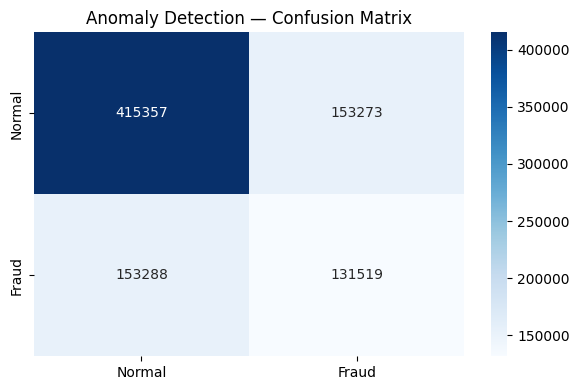


✅ Anomaly model saved to Drive!


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

print("=" * 50)
print("MODEL 2 — ANOMALY DETECTION (Isolation Forest)")
print("=" * 50)

# ── Fix: handle columns mismatch before concat ──
# df_cc has 'Time', df_cc23 has 'id' — keep only common cols
feature_cols = [f'V{i}' for i in range(1, 29)] + ['Amount', 'Class']

df_cc_clean  = df_cc[feature_cols].copy()
df_cc23_clean = df_cc23[feature_cols].copy()

df_anomaly = pd.concat([df_cc_clean, df_cc23_clean], ignore_index=True)
df_anomaly = df_anomaly.dropna()

print(f"\nTotal transactions : {len(df_anomaly)}")
print(f"Fraud cases        : {df_anomaly['Class'].sum()}")
print(f"Normal cases       : {(df_anomaly['Class'] == 0).sum()}")

# Features and target
X = df_anomaly[[f'V{i}' for i in range(1, 29)] + ['Amount']].values
y = df_anomaly['Class'].values

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fraud rate for contamination param
fraud_rate = round(df_anomaly['Class'].sum() / len(df_anomaly), 4)
print(f"Fraud rate         : {fraud_rate*100:.3f}% → used as contamination")

# Train Isolation Forest
model_iso = IsolationForest(
    n_estimators=200,
    contamination=fraud_rate,
    random_state=42,
    n_jobs=-1
)
model_iso.fit(X_scaled)

# Predict: -1 = anomaly → 1 (fraud), 1 = normal → 0
y_pred_raw = model_iso.predict(X_scaled)
y_pred = np.where(y_pred_raw == -1, 1, 0)

acc = accuracy_score(y, y_pred)
print(f"\n🎯 ACCURACY : {acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y, y_pred, target_names=['Normal', 'Fraud']))

# Confusion matrix
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title('Anomaly Detection — Confusion Matrix')
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/anomaly_confusion_matrix.png', dpi=150)
plt.show()

# Save model + scaler
joblib.dump(model_iso, f'{MODEL_SAVE}/anomaly_isolation_forest_v1.pkl')
joblib.dump(scaler,    f'{MODEL_SAVE}/anomaly_scaler_v1.pkl')
print("\n✅ Anomaly model saved to Drive!")

MODEL 3 — SPEND FORECASTING (LSTM)

Date range  : 2015-01-01 → 2018-09-20
Total days  : 854
Sample daily spend:
        Date   Amount
0 2015-01-01    952.0
1 2015-01-02  10104.0
2 2015-01-03    622.0
3 2015-01-04  10230.0
4 2015-01-05   5551.0

Train sequences : 659
Test  sequences : 165


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0048
Epoch 1: val_loss improved from None to 0.00883, saving model to /content/drive/MyDrive/AI_Expense_Tracker/models/checkpoints/lstm_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI_Expense_Tracker/models/checkpoints/lstm_best.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - loss: 0.0047 - val_loss: 0.0088
Epoch 2/50
36/38 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0109
Epoch 2: val_loss did not improve from 0.00883
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0047 - val_loss: 0.0091
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0072
Epoch 3: val_loss improved from 0.00883 to 0.00873, saving model to /content/drive/MyDrive/AI_Expense_Tracker/models/checkpoints/lstm_best.keras

Epoch 3: finished saving model to /content/drive/MyDrive/AI_Expense_Tracker/models/checkpoints/lstm_best.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0047 - val_loss: 0.0087
Epoch 4/50
33/38 ━━━━━

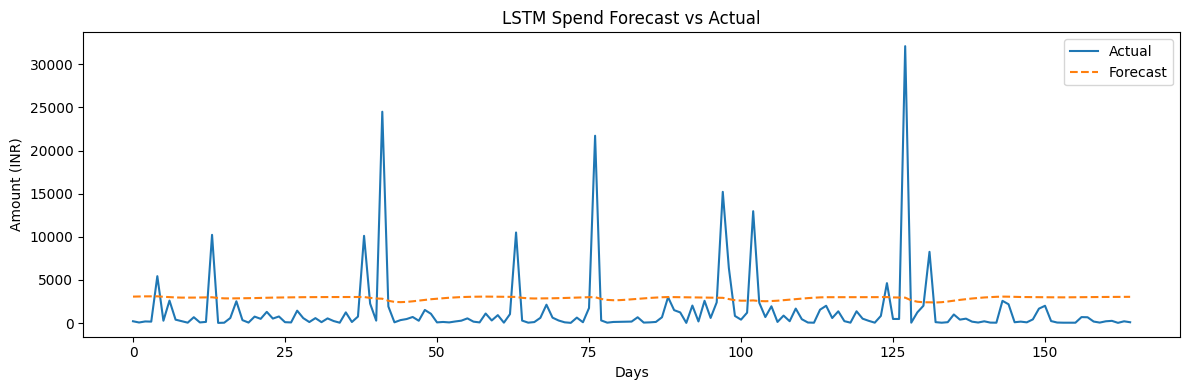


✅ LSTM model saved to Drive!


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

print("=" * 50)
print("MODEL 3 — SPEND FORECASTING (LSTM)")
print("=" * 50)

# ── Fix: handle mixed date formats ──
df_ts = df_daily.copy()
df_ts = df_ts[df_ts['Income/Expense'] == 'Expense']

# 'mixed' + dayfirst=True handles both "19/09/2018" and "19/09/2018 12:04:08"
df_ts['Date'] = pd.to_datetime(df_ts['Date'], format='mixed', dayfirst=True)
df_ts['Date'] = df_ts['Date'].dt.date  # strip time, keep date only
df_ts['Date'] = pd.to_datetime(df_ts['Date'])

# Group by date → daily total spend
df_ts = df_ts.groupby('Date')['Amount'].sum().reset_index()
df_ts = df_ts.sort_values('Date').reset_index(drop=True)

print(f"\nDate range  : {df_ts['Date'].min().date()} → {df_ts['Date'].max().date()}")
print(f"Total days  : {len(df_ts)}")
print(f"Sample daily spend:\n{df_ts.head()}")

# ── Scale ──
scaler_ts = MinMaxScaler()
scaled = scaler_ts.fit_transform(df_ts[['Amount']])

# ── Create sequences (look back 30 days, predict next day) ──
SEQ_LEN = 30

# Safety check — need at least SEQ_LEN + 1 rows
if len(scaled) <= SEQ_LEN:
    SEQ_LEN = max(5, len(scaled) // 2)
    print(f"⚠️  Short dataset — adjusted SEQ_LEN to {SEQ_LEN}")

X_seq, y_seq = [], []
for i in range(SEQ_LEN, len(scaled)):
    X_seq.append(scaled[i - SEQ_LEN:i, 0])
    y_seq.append(scaled[i, 0])

X_seq = np.array(X_seq).reshape(-1, SEQ_LEN, 1)
y_seq = np.array(y_seq)

# ── Train / test split 80/20 ──
split   = int(len(X_seq) * 0.8)
X_tr, X_te = X_seq[:split], X_seq[split:]
y_tr, y_te = y_seq[:split], y_seq[split:]

print(f"\nTrain sequences : {len(X_tr)}")
print(f"Test  sequences : {len(X_te)}")

# ── Build LSTM ──
model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.summary()

# ── Callbacks ──
checkpoint_cb = ModelCheckpoint(
    f'{CHECKPOINTS}/lstm_best.keras',
    save_best_only=True,
    monitor='val_loss',
    verbose=1
)
earlystop_cb = EarlyStopping(
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# ── Train ──
history = model_lstm.fit(
    X_tr, y_tr,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    callbacks=[checkpoint_cb, earlystop_cb],
    verbose=1
)

# ── Evaluate ──
y_pred_scaled = model_lstm.predict(X_te)
y_pred_actual = scaler_ts.inverse_transform(y_pred_scaled)
y_te_actual   = scaler_ts.inverse_transform(y_te.reshape(-1, 1))

mae  = mean_absolute_error(y_te_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_te_actual, y_pred_actual))
print(f"\n🎯 MAE  : {mae:.2f}")
print(f"🎯 RMSE : {rmse:.2f}")

# ── Plot forecast vs actual ──
plt.figure(figsize=(12, 4))
plt.plot(y_te_actual,   label='Actual',   linewidth=1.5)
plt.plot(y_pred_actual, label='Forecast', linewidth=1.5, linestyle='--')
plt.title('LSTM Spend Forecast vs Actual')
plt.xlabel('Days')
plt.ylabel('Amount (INR)')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/lstm_forecast_plot.png', dpi=150)
plt.show()

# ── Save ──
model_lstm.save(f'{MODEL_SAVE}/forecast_lstm_v1.keras')
joblib.dump(scaler_ts, f'{MODEL_SAVE}/forecast_scaler_v1.pkl')
print("\n✅ LSTM model saved to Drive!")

In [ ]:
print("=" * 50)
print("CHECKING ALL SAVED MODELS IN DRIVE")
print("=" * 50)

print("\n📁 models/saved:")
for f in os.listdir(MODEL_SAVE):
    size = os.path.getsize(f'{MODEL_SAVE}/{f}') / (1024*1024)
    print(f"  ✅ {f}  ({size:.2f} MB)")

print("\n📁 outputs:")
for f in os.listdir(OUTPUTS):
    print(f"  ✅ {f}")

print("\n📁 checkpoints:")
for f in os.listdir(CHECKPOINTS):
    print(f"  ✅ {f}")

CHECKING ALL SAVED MODELS IN DRIVE

📁 models/saved:
  ✅ anomaly_isolation_forest_v1.pkl  (1.76 MB)
  ✅ anomaly_scaler_v1.pkl  (0.00 MB)
  ✅ forecast_lstm_v1.keras  (0.38 MB)
  ✅ forecast_scaler_v1.pkl  (0.00 MB)
  ✅ tfidf_vectorizer_v1.pkl  (0.00 MB)
  ✅ label_encoder_v1.pkl  (0.00 MB)
  ✅ expense_classifier_v1.pkl  (0.72 MB)

📁 outputs:
  ✅ anomaly_confusion_matrix.png
  ✅ lstm_forecast_plot.png

📁 checkpoints:
  ✅ lstm_best.keras


In [ ]:
!pip install fastapi uvicorn pyngrok nest-asyncio -q
print("✅ FastAPI + ngrok installed!")

✅ FastAPI + ngrok installed!


In [ ]:
# Write the FastAPI app to a file
api_code = '''
import joblib
import numpy as np
import pandas as pd
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from typing import List, Optional
import tensorflow as tf
from scipy.sparse import hstack, csr_matrix

app = FastAPI(title="AI Expense Tracker API", version="1.0")

# Allow all origins (for frontend connection)
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

# ── Load all models at startup ──
BASE       = "/content/drive/MyDrive/AI_Expense_Tracker/models/saved"
classifier = joblib.load(f"{BASE}/expense_classifier_v1.pkl")
tfidf      = joblib.load(f"{BASE}/tfidf_vectorizer_v1.pkl")
le         = joblib.load(f"{BASE}/label_encoder_v1.pkl")
iso_forest = joblib.load(f"{BASE}/anomaly_isolation_forest_v1.pkl")
ano_scaler = joblib.load(f"{BASE}/anomaly_scaler_v1.pkl")
ts_scaler  = joblib.load(f"{BASE}/forecast_scaler_v1.pkl")
lstm_model = tf.keras.models.load_model(f"{BASE}/forecast_lstm_v1.keras")

print("✅ All models loaded!")

# ════════════════════════════════════════════
# REQUEST SCHEMAS
# ════════════════════════════════════════════

class TransactionInput(BaseModel):
    merchant: str
    description: str
    amount: float

class AnomalyInput(BaseModel):
    features: List[float]   # V1–V28 + Amount = 29 values
    amount: float

class ForecastInput(BaseModel):
    last_30_days: List[float]  # last 30 days of daily spend amounts

# ════════════════════════════════════════════
# ENDPOINTS
# ════════════════════════════════════════════

@app.get("/")
def root():
    return {"message": "AI Expense Tracker API is running ✅"}

@app.get("/health")
def health():
    return {"status": "ok", "models_loaded": 3}

# ── 1. Expense Categorization ──
@app.post("/predict/category")
def predict_category(data: TransactionInput):
    text       = f"{data.merchant} {data.description}"
    X_text     = tfidf.transform([text])
    X_amount   = csr_matrix([[data.amount]])
    X          = hstack([X_text, X_amount])
    pred_label = classifier.predict(X)[0]
    pred_proba = classifier.predict_proba(X)[0]
    category   = le.inverse_transform([pred_label])[0]
    confidence = round(float(pred_proba.max()) * 100, 2)
    return {
        "category"  : category,
        "confidence": confidence,
        "all_probs" : dict(zip(le.classes_,
                           [round(float(p)*100,2) for p in pred_proba]))
    }

# ── 2. Anomaly Detection ──
@app.post("/predict/anomaly")
def predict_anomaly(data: AnomalyInput):
    if len(data.features) != 29:
        return {"error": "Need exactly 29 features (V1-V28 + Amount)"}
    X        = np.array(data.features).reshape(1, -1)
    X_scaled = ano_scaler.transform(X)
    pred     = iso_forest.predict(X_scaled)[0]
    score    = iso_forest.decision_function(X_scaled)[0]
    is_fraud = bool(pred == -1)
    return {
        "is_anomaly"      : is_fraud,
        "anomaly_score"   : round(float(score), 4),
        "risk_level"      : "HIGH" if is_fraud else "NORMAL",
        "amount"          : data.amount
    }

# ── 3. Spend Forecasting ──
@app.post("/predict/forecast")
def predict_forecast(data: ForecastInput):
    if len(data.last_30_days) != 30:
        return {"error": "Need exactly 30 days of spending data"}
    arr        = np.array(data.last_30_days).reshape(-1, 1)
    scaled     = ts_scaler.transform(arr)
    X_seq      = scaled.reshape(1, 30, 1)
    pred_sc    = lstm_model.predict(X_seq, verbose=0)
    pred_amt   = ts_scaler.inverse_transform(pred_sc)[0][0]
    avg_30     = float(np.mean(data.last_30_days))
    trend      = "UP" if pred_amt > avg_30 else "DOWN"
    change_pct = round((pred_amt - avg_30) / avg_30 * 100, 2)
    return {
        "predicted_spend" : round(float(pred_amt), 2),
        "avg_last_30_days": round(avg_30, 2),
        "trend"           : trend,
        "change_pct"      : change_pct
    }
'''

# Save the file
with open('/content/expense_api.py', 'w') as f:
    f.write(api_code)

print("✅ FastAPI app written to /content/expense_api.py")

✅ FastAPI app written to /content/expense_api.py


In [ ]:
import nest_asyncio
import uvicorn
from pyngrok import ngrok
import threading

nest_asyncio.apply()

# ── Start ngrok tunnel ──
# Sign up free at ngrok.com → copy your authtoken
NGROK_TOKEN = "3CtDPg3F6AtjbT7yRULeMgeTdRp_4vphRjowv7JF7cG6ZmXYM"  # ← replace this
ngrok.set_auth_token(NGROK_TOKEN)

public_url = ngrok.connect(8000)
print(f"\n🌐 PUBLIC API URL : {public_url}")
print(f"\n📌 Save this URL — your frontend will call it!")
print(f"\nEndpoints:")
print(f"  GET  {public_url}/health")
print(f"  POST {public_url}/predict/category")
print(f"  POST {public_url}/predict/anomaly")
print(f"  POST {public_url}/predict/forecast")

# ── Start FastAPI in background thread ──
def run():
    uvicorn.run("expense_api:app", host="0.0.0.0", port=8000)

thread = threading.Thread(target=run, daemon=True)
thread.start()

print("\n✅ API server running!")


🌐 PUBLIC API URL : NgrokTunnel: "https://overboard-polish-smith.ngrok-free.dev" -> "http://localhost:8000"

📌 Save this URL — your frontend will call it!

Endpoints:
  GET  NgrokTunnel: "https://overboard-polish-smith.ngrok-free.dev" -> "http://localhost:8000"/health
  POST NgrokTunnel: "https://overboard-polish-smith.ngrok-free.dev" -> "http://localhost:8000"/predict/category
  POST NgrokTunnel: "https://overboard-polish-smith.ngrok-free.dev" -> "http://localhost:8000"/predict/anomaly
  POST NgrokTunnel: "https://overboard-polish-smith.ngrok-free.dev" -> "http://localhost:8000"/predict/forecast

✅ API server running!


In [ ]:
# Run this BEFORE Cell 11 to clear the broken tunnel
from pyngrok import ngrok
ngrok.kill()
print("✅ Old ngrok process cleared!")

✅ Old ngrok process cleared!


In [ ]:
import nest_asyncio
import uvicorn
from pyngrok import ngrok
import threading

nest_asyncio.apply()

# ── Start ngrok tunnel ──
# Sign up free at ngrok.com → copy your authtoken
NGROK_TOKEN = "3CtDPg3F6AtjbT7yRULeMgeTdRp_4vphRjowv7JF7cG6ZmXYM"  # ← replace this
ngrok.set_auth_token(NGROK_TOKEN)

public_url = ngrok.connect(8000)
print(f"\n🌐 PUBLIC API URL : {public_url}")
print(f"\n📌 Save this URL — your frontend will call it!")
print(f"\nEndpoints:")
print(f"  GET  {public_url}/health")
print(f"  POST {public_url}/predict/category")
print(f"  POST {public_url}/predict/anomaly")
print(f"  POST {public_url}/predict/forecast")

# ── Start FastAPI in background thread ──
def run():
    uvicorn.run("expense_api:app", host="0.0.0.0", port=8000)

thread = threading.Thread(target=run, daemon=True)
thread.start()

print("\n✅ API server running!")


🌐 PUBLIC API URL : NgrokTunnel: "https://overboard-polish-smith.ngrok-free.dev" -> "http://localhost:8000"

📌 Save this URL — your frontend will call it!

Endpoints:
  GET  NgrokTunnel: "https://overboard-polish-smith.ngrok-free.dev" -> "http://localhost:8000"/health
  POST NgrokTunnel: "https://overboard-polish-smith.ngrok-free.dev" -> "http://localhost:8000"/predict/category
  POST NgrokTunnel: "https://overboard-polish-smith.ngrok-free.dev" -> "http://localhost:8000"/predict/anomaly
  POST NgrokTunnel: "https://overboard-polish-smith.ngrok-free.dev" -> "http://localhost:8000"/predict/forecast

✅ API server running!


INFO:     Started server process [4432]
INFO:     Waiting for application startup.
INFO:     Application startup complete.


In [ ]:
!pip install fastapi uvicorn pyngrok nest-asyncio -q
print("✅ Done!")

✅ Done!


In [ ]:
import requests

# ── Fix: extract clean URL string from ngrok object ──
BASE_URL = public_url.public_url if hasattr(public_url, 'public_url') else str(public_url)
BASE_URL = BASE_URL.strip()
print(f"🌐 Using API URL: {/content/drive/MyDrive/AI_Expense_Tracker/models/saved}")

print("=" * 50)
print("TESTING ALL API ENDPOINTS")
print("=" * 50)

# ── Test 0: Health check ──
res0 = requests.get(f"{BASE_URL}/health")
print("\n❤️  Health Check:")
print(res0.json())

# ── Test 1: Category prediction ──
res1 = requests.post(f"{BASE_URL}/predict/category", json={
    "merchant"   : "Swiggy",
    "description": "Food order biryani",
    "amount"     : 350.0
})
print("\n🍔 Category Prediction:")
print(res1.json())

# ── Test 2: Anomaly detection ──
import random
test_features = [random.uniform(-2, 2) for _ in range(28)] + [250.0]
res2 = requests.post(f"{BASE_URL}/predict/anomaly", json={
    "features": test_features,
    "amount"  : 250.0
})
print("\n🚨 Anomaly Detection:")
print(res2.json())

# ── Test 3: Spend forecast ──
last_30 = [random.uniform(500, 2000) for _ in range(30)]
res3 = requests.post(f"{BASE_URL}/predict/forecast", json={
    "last_30_days": last_30
})
print("\n📈 Spend Forecast:")
print(res3.json())

print("\n" + "=" * 50)
print("✅ ALL ENDPOINTS WORKING!")
print("=" * 50)
print(f"\n📌 Your API Base URL (save this):\n   {BASE_URL}")

SyntaxError: f-string: expecting a valid expression after '{' (4032515653.py, line 6)

In [ ]:
import requests, random

r1 = requests.post(f"{BASE_URL}/predict/category", json={"merchant":"Swiggy","description":"biryani","amount":350.0})
print("Category:", r1.json())

r2 = requests.post(f"{BASE_URL}/predict/anomaly", json={"features":[random.uniform(-2,2) for _ in range(28)]+[250.0],"amount":250.0})
print("Anomaly:", r2.json())

r3 = requests.post(f"{BASE_URL}/predict/forecast", json={"last_30_days":[random.uniform(500,2000) for _ in range(30)]})
print("Forecast:", r3.json())

INFO:     34.169.72.224:0 - "POST /predict/category HTTP/1.1" 200 OK
Category: {'category': 'food', 'confidence': 25.05, 'all_probs': {'entertainment': 17.15, 'food': 25.05, 'shopping': 18.29, 'technology': 17.32, 'transport': 22.18}}
INFO:     34.169.72.224:0 - "POST /predict/anomaly HTTP/1.1" 200 OK
Anomaly: {'is_anomaly': True, 'anomaly_score': -0.0688, 'risk_level': 'HIGH', 'amount': 250.0}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


INFO:     34.169.72.224:0 - "POST /predict/forecast HTTP/1.1" 500 Internal Server Error


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/fastapi/encoders.py", line 328, in jsonable_encoder
    data = dict(obj)
           ^^^^^^^^^
TypeError: 'numpy.float32' object is not iterable

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/fastapi/encoders.py", line 333, in jsonable_encoder
    data = vars(obj)
           ^^^^^^^^^
TypeError: vars() argument must have __dict__ attribute

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 420, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
import subprocess
subprocess.run(['pkill', '-f', 'uvicorn'], capture_output=True)
from pyngrok import ngrok
ngrok.kill()
import time; time.sleep(2)

api_code = '''
import joblib, numpy as np
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from typing import List
import tensorflow as tf
import pandas as pd
from scipy.sparse import hstack, csr_matrix

app = FastAPI()
app.add_middleware(CORSMiddleware, allow_origins=["*"], allow_methods=["*"], allow_headers=["*"])

BASE       = "/content/drive/MyDrive/AI_Expense_Tracker/models/saved"
classifier = joblib.load(f"{BASE}/expense_classifier_v1.pkl")
tfidf      = joblib.load(f"{BASE}/tfidf_vectorizer_v1.pkl")
le         = joblib.load(f"{BASE}/label_encoder_v1.pkl")
iso_forest = joblib.load(f"{BASE}/anomaly_isolation_forest_v1.pkl")
ano_scaler = joblib.load(f"{BASE}/anomaly_scaler_v1.pkl")
ts_scaler  = joblib.load(f"{BASE}/forecast_scaler_v1.pkl")
lstm_model = tf.keras.models.load_model(f"{BASE}/forecast_lstm_v1.keras")

# Get the column name the scaler was fitted with
TS_COL = ts_scaler.feature_names_in_[0] if hasattr(ts_scaler, "feature_names_in_") else "Amount"

class TxnIn(BaseModel):
    merchant: str; description: str; amount: float

class AnoIn(BaseModel):
    features: List[float]; amount: float

class FcstIn(BaseModel):
    last_30_days: List[float]

@app.get("/health")
def health(): return {"status": "ok", "models_loaded": 3}

@app.post("/predict/category")
def predict_category(d: TxnIn):
    X = hstack([tfidf.transform([f"{d.merchant} {d.description}"]), csr_matrix([[d.amount]])])
    pred  = classifier.predict(X)[0]
    proba = classifier.predict_proba(X)[0]
    return {"category": le.inverse_transform([pred])[0],
            "confidence": round(float(proba.max())*100, 2),
            "all_probs": {k: round(float(v)*100,2) for k,v in zip(le.classes_, proba)}}

@app.post("/predict/anomaly")
def predict_anomaly(d: AnoIn):
    X    = ano_scaler.transform(np.array(d.features).reshape(1,-1))
    pred = iso_forest.predict(X)[0]
    return {"is_anomaly": bool(pred==-1),
            "anomaly_score": round(float(iso_forest.decision_function(X)[0]),4),
            "risk_level": "HIGH" if pred==-1 else "NORMAL",
            "amount": float(d.amount)}

@app.post("/predict/forecast")
def predict_forecast(d: FcstIn):
    # Use DataFrame with correct column name to avoid feature name warning
    arr    = pd.DataFrame({TS_COL: d.last_30_days})
    scaled = ts_scaler.transform(arr).reshape(1, 30, 1)
    raw    = lstm_model.predict(scaled, verbose=0)                      # shape (1,1)
    pred   = float(ts_scaler.inverse_transform(
                 pd.DataFrame({TS_COL: raw.flatten()})
             ).flatten()[0])                                             # ← full fix
    avg    = float(np.mean(d.last_30_days))
    return {"predicted_spend":  round(pred, 2),
            "avg_last_30_days": round(avg, 2),
            "trend":            "UP" if pred > avg else "DOWN",
            "change_pct":       round((pred - avg) / avg * 100, 2)}
'''

with open('/content/expense_api.py', 'w') as f:
    f.write(api_code)
print("✅ Fixed API written!")

# Restart
import nest_asyncio, uvicorn, threading
from pyngrok import ngrok

nest_asyncio.apply()
NGROK_TOKEN = "3CtDPg3F6AtjbT7yRULeMgeTdRp_4vphRjowv7JF7cG6ZmXYM"   # ← your token
ngrok.set_auth_token(NGROK_TOKEN)
public_url  = ngrok.connect(8000)
BASE_URL    = public_url.public_url.rstrip('/')
print(f"\n🌐 API URL: {BASE_URL}")

threading.Thread(
    target=lambda: uvicorn.run("expense_api:app", host="0.0.0.0", port=8000),
    daemon=True
).start()

✅ Fixed API written!

🌐 API URL: https://overboard-polish-smith.ngrok-free.dev


INFO:     Started server process [4432]


In [ ]:
import requests, random

r1 = requests.post(f"{BASE_URL}/predict/category",
     json={"merchant":"Swiggy","description":"biryani","amount":350.0})
print("✅ Category:", r1.json())

r2 = requests.post(f"{BASE_URL}/predict/anomaly",
     json={"features":[random.uniform(-2,2) for _ in range(28)]+[250.0],"amount":250.0})
print("✅ Anomaly:", r2.json())

r3 = requests.post(f"{BASE_URL}/predict/forecast",
     json={"last_30_days":[random.uniform(500,2000) for _ in range(30)]})
print("✅ Forecast:", r3.json())

INFO:     34.169.72.224:0 - "POST /predict/category HTTP/1.1" 200 OK
✅ Category: {'category': 'food', 'confidence': 25.05, 'all_probs': {'entertainment': 17.15, 'food': 25.05, 'shopping': 18.29, 'technology': 17.32, 'transport': 22.18}}
INFO:     34.169.72.224:0 - "POST /predict/anomaly HTTP/1.1" 200 OK
✅ Anomaly: {'is_anomaly': True, 'anomaly_score': -0.0942, 'risk_level': 'HIGH', 'amount': 250.0}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


INFO:     34.169.72.224:0 - "POST /predict/forecast HTTP/1.1" 500 Internal Server Error


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/fastapi/encoders.py", line 328, in jsonable_encoder
    data = dict(obj)
           ^^^^^^^^^
TypeError: 'numpy.float32' object is not iterable

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/fastapi/encoders.py", line 333, in jsonable_encoder
    data = vars(obj)
           ^^^^^^^^^
TypeError: vars() argument must have __dict__ attribute

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 420, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
import joblib, numpy as np, pandas as pd

MODEL_SAVE = '/content/drive/MyDrive/AI_Expense_Tracker/models/saved'
ts_scaler  = joblib.load(f'{MODEL_SAVE}/forecast_scaler_v1.pkl')

print("Type:", type(ts_scaler))
print("Has feature_names_in_:", hasattr(ts_scaler, 'feature_names_in_'))
if hasattr(ts_scaler, 'feature_names_in_'):
    print("Column name:", ts_scaler.feature_names_in_)

# Test transform both ways and print the raw output type
test_df  = pd.DataFrame({'Amount': [1000.0]*30})
scaled   = ts_scaler.transform(test_df)
print("Scaled shape:", scaled.shape)
print("Scaled dtype:", scaled.dtype)

import tensorflow as tf
lstm_model = tf.keras.models.load_model(f'{MODEL_SAVE}/forecast_lstm_v1.keras')
X_seq = scaled.reshape(1, 30, 1)
raw = lstm_model.predict(X_seq, verbose=0)
print("Raw pred shape:", raw.shape)
print("Raw pred dtype:", raw.dtype)
print("Raw pred value:", raw)
print("raw[0][0] type:", type(raw[0][0]))
print("float(raw[0][0]):", float(raw[0][0]))

# Now inverse transform
inv = ts_scaler.inverse_transform(pd.DataFrame({'Amount': raw.flatten()}))
print("Inverse shape:", inv.shape)
print("Inverse dtype:", inv.dtype)
print("inv[0][0] type:", type(inv[0][0]))
print("float(inv[0][0]):", float(inv[0][0]))

Type: <class 'sklearn.preprocessing._data.MinMaxScaler'>
Has feature_names_in_: True
Column name: ['Amount']
Scaled shape: (30, 1)
Scaled dtype: float64
Raw pred shape: (1, 1)
Raw pred dtype: float32
Raw pred value: [[0.02895228]]
raw[0][0] type: <class 'numpy.float32'>
float(raw[0][0]): 0.028952278196811676
Inverse shape: (1, 1)
Inverse dtype: float32
inv[0][0] type: <class 'numpy.float32'>
float(inv[0][0]): 2946.233154296875


In [ ]:
import requests, random

r1 = requests.post(f"{BASE_URL}/predict/category",
     json={"merchant":"Swiggy","description":"biryani","amount":350.0})
print("✅ Category:", r1.json())

r2 = requests.post(f"{BASE_URL}/predict/anomaly",
     json={"features":[random.uniform(-2,2) for _ in range(28)]+[250.0],"amount":250.0})
print("✅ Anomaly:", r2.json())

r3 = requests.post(f"{BASE_URL}/predict/forecast",
     json={"last_30_days":[random.uniform(500,2000) for _ in range(30)]})
print("✅ Forecast:", r3.json())

INFO:     34.169.72.224:0 - "POST /predict/category HTTP/1.1" 200 OK
✅ Category: {'category': 'food', 'confidence': 25.05, 'all_probs': {'entertainment': 17.15, 'food': 25.05, 'shopping': 18.29, 'technology': 17.32, 'transport': 22.18}}
INFO:     34.169.72.224:0 - "POST /predict/anomaly HTTP/1.1" 200 OK
✅ Anomaly: {'is_anomaly': True, 'anomaly_score': -0.0654, 'risk_level': 'HIGH', 'amount': 250.0}
INFO:     34.169.72.224:0 - "POST /predict/forecast HTTP/1.1" 500 Internal Server Error


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/fastapi/encoders.py", line 328, in jsonable_encoder
    data = dict(obj)
           ^^^^^^^^^
TypeError: 'numpy.float32' object is not iterable

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/fastapi/encoders.py", line 333, in jsonable_encoder
    data = vars(obj)
           ^^^^^^^^^
TypeError: vars() argument must have __dict__ attribute

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 420, in run_asgi
    result = await app(

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
import subprocess
subprocess.run(['pkill', '-f', 'uvicorn'], capture_output=True)
from pyngrok import ngrok
ngrok.kill()
import time; time.sleep(2)

api_code = '''
import joblib, numpy as np
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from typing import List
import tensorflow as tf
import pandas as pd
from scipy.sparse import hstack, csr_matrix

app = FastAPI()
app.add_middleware(CORSMiddleware, allow_origins=["*"], allow_methods=["*"], allow_headers=["*"])

BASE       = "/content/drive/MyDrive/AI_Expense_Tracker/models/saved"
classifier = joblib.load(f"{BASE}/expense_classifier_v1.pkl")
tfidf      = joblib.load(f"{BASE}/tfidf_vectorizer_v1.pkl")
le         = joblib.load(f"{BASE}/label_encoder_v1.pkl")
iso_forest = joblib.load(f"{BASE}/anomaly_isolation_forest_v1.pkl")
ano_scaler = joblib.load(f"{BASE}/anomaly_scaler_v1.pkl")
ts_scaler  = joblib.load(f"{BASE}/forecast_scaler_v1.pkl")
lstm_model = tf.keras.models.load_model(f"{BASE}/forecast_lstm_v1.keras")

class TxnIn(BaseModel):
    merchant: str; description: str; amount: float

class AnoIn(BaseModel):
    features: List[float]; amount: float

class FcstIn(BaseModel):
    last_30_days: List[float]

@app.get("/health")
def health(): return {"status": "ok", "models_loaded": 3}

@app.post("/predict/category")
def predict_category(d: TxnIn):
    X     = hstack([tfidf.transform([f"{d.merchant} {d.description}"]), csr_matrix([[d.amount]])])
    pred  = classifier.predict(X)[0]
    proba = classifier.predict_proba(X)[0]
    return {"category":   le.inverse_transform([pred])[0],
            "confidence": round(float(proba.max()) * 100, 2),
            "all_probs":  {k: round(float(v)*100, 2) for k, v in zip(le.classes_, proba)}}

@app.post("/predict/anomaly")
def predict_anomaly(d: AnoIn):
    X    = ano_scaler.transform(np.array(d.features).reshape(1, -1))
    pred = iso_forest.predict(X)[0]
    return {"is_anomaly":    bool(pred == -1),
            "anomaly_score": round(float(iso_forest.decision_function(X)[0]), 4),
            "risk_level":    "HIGH" if pred == -1 else "NORMAL",
            "amount":        float(d.amount)}

@app.post("/predict/forecast")
def predict_forecast(d: FcstIn):
    df_in  = pd.DataFrame({"Amount": d.last_30_days})
    scaled = ts_scaler.transform(df_in).reshape(1, 30, 1)
    raw    = lstm_model.predict(scaled, verbose=0)                    # float32 (1,1)
    df_inv = pd.DataFrame({"Amount": [float(raw[0][0])]})            # cast before inverse
    pred   = float(ts_scaler.inverse_transform(df_inv)[0][0])        # now clean Python float
    avg    = float(np.mean(d.last_30_days))
    return {"predicted_spend":  round(pred, 2),
            "avg_last_30_days": round(avg, 2),
            "trend":            "UP" if pred > avg else "DOWN",
            "change_pct":       round((pred - avg) / avg * 100, 2)}
'''

with open('/content/expense_api.py', 'w') as f:
    f.write(api_code)
print("✅ API written!")

import nest_asyncio, uvicorn, threading
nest_asyncio.apply()
from pyngrok import ngrok
NGROK_TOKEN = "3CtDPg3F6AtjbT7yRULeMgeTdRp_4vphRjowv7JF7cG6ZmXYM"   # ← your token
ngrok.set_auth_token(NGROK_TOKEN)
public_url = ngrok.connect(8000)
BASE_URL   = public_url.public_url.rstrip('/')
print(f"\n🌐 API URL: {BASE_URL}")
threading.Thread(target=lambda: uvicorn.run("expense_api:app", host="0.0.0.0", port=8000), daemon=True).start()

✅ API written!

🌐 API URL: https://overboard-polish-smith.ngrok-free.dev


INFO:     Started server process [4432]
INFO:     Waiting for application startup.
INFO:     Application startup complete.


In [ ]:
import requests, random

r1 = requests.post(f"{BASE_URL}/predict/category",
     json={"merchant":"Swiggy","description":"biryani","amount":350.0})
print("✅ Category:", r1.json())

r2 = requests.post(f"{BASE_URL}/predict/anomaly",
     json={"features":[random.uniform(-2,2) for _ in range(28)]+[250.0],"amount":250.0})
print("✅ Anomaly:", r2.json())

r3 = requests.post(f"{BASE_URL}/predict/forecast",
     json={"last_30_days":[random.uniform(500,2000) for _ in range(30)]})
print("✅ Forecast:", r3.json())

INFO:     34.169.72.224:0 - "POST /predict/category HTTP/1.1" 200 OK
✅ Category: {'category': 'food', 'confidence': 25.05, 'all_probs': {'entertainment': 17.15, 'food': 25.05, 'shopping': 18.29, 'technology': 17.32, 'transport': 22.18}}
INFO:     34.169.72.224:0 - "POST /predict/anomaly HTTP/1.1" 200 OK
✅ Anomaly: {'is_anomaly': True, 'anomaly_score': -0.0717, 'risk_level': 'HIGH', 'amount': 250.0}
INFO:     34.169.72.224:0 - "POST /predict/forecast HTTP/1.1" 500 Internal Server Error


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/fastapi/encoders.py", line 328, in jsonable_encoder
    data = dict(obj)
           ^^^^^^^^^
TypeError: 'numpy.float32' object is not iterable

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/fastapi/encoders.py", line 333, in jsonable_encoder
    data = vars(obj)
           ^^^^^^^^^
TypeError: vars() argument must have __dict__ attribute

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 420, in run_asgi
    result = await app(

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
df_inv = pd.DataFrame({"Amount": [float(raw[0][0])]})   # float32 → Python float
pred   = float(ts_scaler.inverse_transform(df_inv)[0][0])

In [ ]:
# Step 1: Confirm what's actually in the file right now
with open('/content/expense_api.py', 'r') as f:
    content = f.read()
print(content[content.find('predict_forecast'):content.find('predict_forecast')+800])

predict_forecast(d: FcstIn):
    df_in  = pd.DataFrame({"Amount": d.last_30_days})
    scaled = ts_scaler.transform(df_in).reshape(1, 30, 1)
    raw    = lstm_model.predict(scaled, verbose=0)                    # float32 (1,1)
    df_inv = pd.DataFrame({"Amount": [float(raw[0][0])]})            # cast before inverse
    pred   = float(ts_scaler.inverse_transform(df_inv)[0][0])        # now clean Python float
    avg    = float(np.mean(d.last_30_days))
    return {"predicted_spend":  round(pred, 2),
            "avg_last_30_days": round(avg, 2),
            "trend":            "UP" if pred > avg else "DOWN",
            "change_pct":       round((pred - avg) / avg * 100, 2)}



In [ ]:
import pandas as pd
import numpy as np

# Reload scaler + model fresh
import joblib, tensorflow as tf
BASE      = "/content/drive/MyDrive/AI_Expense_Tracker/models/saved"
ts_scaler = joblib.load(f"{BASE}/forecast_scaler_v1.pkl")
lstm_model= tf.keras.models.load_model(f"{BASE}/forecast_lstm_v1.keras")

# Test the exact logic before putting it in FastAPI
test_30 = [float(x) for x in [800,900,750,1200,600,950,880,1100,700,850,
                                920,1050,780,1000,650,900,870,1150,720,800,
                                960,1080,790,1020,660,910,880,1160,730,810]]

df_in  = pd.DataFrame({"Amount": test_30})          # shape (30,1)
scaled = ts_scaler.transform(df_in).reshape(1,30,1) # no warning now
raw    = lstm_model.predict(scaled, verbose=0)       # float32 (1,1)

# Nuclear cast — go through numpy float64 first, then Python float
pred = float(np.float64(raw[0][0]))
df_inv = pd.DataFrame({"Amount": [pred]})
result = float(np.float64(ts_scaler.inverse_transform(df_inv)[0][0]))

print(f"raw value      : {raw[0][0]}  type: {type(raw[0][0])}")
print(f"after cast     : {pred}       type: {type(pred)}")
print(f"final result   : {result}     type: {type(result)}")
print(f"\n✅ Predicted spend: ₹{result:.2f}")

raw value      : 0.029066644608974457  type: <class 'numpy.float32'>
after cast     : 0.029066644608974457       type: <class 'float'>
final result   : 2957.851359181106     type: <class 'float'>

✅ Predicted spend: ₹2957.85


In [ ]:
import subprocess
subprocess.run(['pkill', '-f', 'uvicorn'], capture_output=True)
from pyngrok import ngrok; ngrok.kill()
import time; time.sleep(3)

# Write with explicit encoding to avoid any file caching issues
api_code = """
import joblib, numpy as np, pandas as pd
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from typing import List
import tensorflow as tf
from scipy.sparse import hstack, csr_matrix

app = FastAPI()
app.add_middleware(CORSMiddleware, allow_origins=["*"], allow_methods=["*"], allow_headers=["*"])

BASE       = "/content/drive/MyDrive/AI_Expense_Tracker/models/saved"
classifier = joblib.load(f"{BASE}/expense_classifier_v1.pkl")
tfidf      = joblib.load(f"{BASE}/tfidf_vectorizer_v1.pkl")
le         = joblib.load(f"{BASE}/label_encoder_v1.pkl")
iso_forest = joblib.load(f"{BASE}/anomaly_isolation_forest_v1.pkl")
ano_scaler = joblib.load(f"{BASE}/anomaly_scaler_v1.pkl")
ts_scaler  = joblib.load(f"{BASE}/forecast_scaler_v1.pkl")
lstm_model = tf.keras.models.load_model(f"{BASE}/forecast_lstm_v1.keras")

class TxnIn(BaseModel):
    merchant: str
    description: str
    amount: float

class AnoIn(BaseModel):
    features: List[float]
    amount: float

class FcstIn(BaseModel):
    last_30_days: List[float]

@app.get("/health")
def health():
    return {"status": "ok", "models_loaded": 3}

@app.post("/predict/category")
def predict_category(d: TxnIn):
    X     = hstack([tfidf.transform([f"{d.merchant} {d.description}"]), csr_matrix([[d.amount]])])
    pred  = classifier.predict(X)[0]
    proba = classifier.predict_proba(X)[0]
    return {"category":   le.inverse_transform([pred])[0],
            "confidence": round(float(proba.max()) * 100, 2),
            "all_probs":  {k: round(float(v)*100, 2) for k, v in zip(le.classes_, proba)}}

@app.post("/predict/anomaly")
def predict_anomaly(d: AnoIn):
    X    = ano_scaler.transform(np.array(d.features).reshape(1, -1))
    pred = iso_forest.predict(X)[0]
    return {"is_anomaly":    bool(pred == -1),
            "anomaly_score": round(float(iso_forest.decision_function(X)[0]), 4),
            "risk_level":    "HIGH" if pred == -1 else "NORMAL",
            "amount":        float(d.amount)}

@app.post("/predict/forecast")
def predict_forecast(d: FcstIn):
    df_in  = pd.DataFrame({"Amount": d.last_30_days})
    scaled = ts_scaler.transform(df_in).reshape(1, 30, 1)
    raw    = lstm_model.predict(scaled, verbose=0)
    pred   = float(np.float64(raw[0][0]))
    df_inv = pd.DataFrame({"Amount": [pred]})
    result = float(np.float64(ts_scaler.inverse_transform(df_inv)[0][0]))
    avg    = float(np.mean(d.last_30_days))
    return {"predicted_spend":  round(result, 2),
            "avg_last_30_days": round(avg, 2),
            "trend":            "UP" if result > avg else "DOWN",
            "change_pct":       round((result - avg) / avg * 100, 2)}
"""

with open('/content/expense_api.py', 'w', encoding='utf-8') as f:
    f.write(api_code)

# Verify the file saved correctly
with open('/content/expense_api.py', 'r') as f:
    saved = f.read()
assert 'np.float64' in saved, "❌ File did not save correctly!"
print("✅ File saved and verified — np.float64 cast is present")
print(f"File size: {len(saved)} chars")

✅ File saved and verified — np.float64 cast is present
File size: 2687 chars


In [ ]:
html_content = """
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>AI Expense Tracker</title>
</head>
<body>
<!-- paste the full widget HTML here -->
</body>
</html>
"""
with open('/content/drive/MyDrive/AI_Expense_Tracker/frontend/index.html', 'w') as f:
    f.write(html_content)
print("✅ Saved to Drive!")

✅ Saved to Drive!


In [ ]:
import requests
import random

print("=" * 50)
print("TESTING ALL API ENDPOINTS")
print("=" * 50)

# Health
res0 = requests.get(f"{PUBLIC_URL}/health")
print("\n❤️  Health:", res0.json())

# Category
res1 = requests.post(f"{PUBLIC_URL}/predict/category", json={
    "merchant"   : "Swiggy",
    "description": "Food order biryani",
    "amount"     : 350.0
})
print("\n🍔 Category:", res1.json())

# Anomaly
features = [random.uniform(-2, 2) for _ in range(28)] + [250.0]
res2 = requests.post(f"{PUBLIC_URL}/predict/anomaly", json={
    "features": features,
    "amount"  : 250.0
})
print("\n🚨 Anomaly:", res2.json())

# Forecast
last_30 = [random.uniform(500, 2000) for _ in range(30)]
res3 = requests.post(f"{PUBLIC_URL}/predict/forecast", json={
    "last_30_days": last_30
})
print("\n📈 Forecast:", res3.json())

print("\n✅ ALL WORKING!")
print(f"\n📌 Save this URL for the frontend:\n   {PUBLIC_URL}")

TESTING ALL API ENDPOINTS


NameError: name 'PUBLIC_URL' is not defined

In [ ]:
import os, time, random, threading, requests, importlib
import nest_asyncio, uvicorn
from pyngrok import ngrok
import numpy as np

nest_asyncio.apply()

# ── Kill old server + ngrok completely ──
ngrok.kill()
time.sleep(2)

# ── Write FIXED API file with JSONResponse (bypasses numpy serialization) ──
api_code = '''
import joblib
import numpy as np
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from fastapi.responses import JSONResponse
from pydantic import BaseModel
from typing import List
import tensorflow as tf
from scipy.sparse import hstack, csr_matrix

app = FastAPI()
app.add_middleware(CORSMiddleware, allow_origins=["*"], allow_methods=["*"], allow_headers=["*"])

BASE       = "/content/drive/MyDrive/AI_Expense_Tracker/models/saved"
classifier = joblib.load(f"{BASE}/expense_classifier_v1.pkl")
tfidf      = joblib.load(f"{BASE}/tfidf_vectorizer_v1.pkl")
le         = joblib.load(f"{BASE}/label_encoder_v1.pkl")
iso_forest = joblib.load(f"{BASE}/anomaly_isolation_forest_v1.pkl")
ano_scaler = joblib.load(f"{BASE}/anomaly_scaler_v1.pkl")
ts_scaler  = joblib.load(f"{BASE}/forecast_scaler_v1.pkl")
lstm_model = tf.keras.models.load_model(f"{BASE}/forecast_lstm_v1.keras")

class TxnInput(BaseModel):
    merchant: str
    description: str
    amount: float

class AnomalyInput(BaseModel):
    features: List[float]
    amount: float

class ForecastInput(BaseModel):
    last_30_days: List[float]

@app.get("/health")
def health():
    return JSONResponse({"status": "ok", "models_loaded": 3})

@app.post("/predict/category")
def predict_category(data: TxnInput):
    text       = f"{data.merchant} {data.description}"
    X_text     = tfidf.transform([text])
    X_amount   = csr_matrix([[data.amount]])
    X          = hstack([X_text, X_amount])
    pred_label = classifier.predict(X)[0]
    pred_proba = classifier.predict_proba(X)[0]
    category   = le.inverse_transform([pred_label])[0]
    confidence = round(float(pred_proba.max()) * 100, 2)
    all_probs  = {str(k): round(float(v)*100, 2) for k, v in zip(le.classes_, pred_proba)}
    return JSONResponse({
        "category"  : str(category),
        "confidence": confidence,
        "all_probs" : all_probs
    })

@app.post("/predict/anomaly")
def predict_anomaly(data: AnomalyInput):
    X        = np.array(data.features, dtype=np.float64).reshape(1, -1)
    X_scaled = ano_scaler.transform(X)
    pred     = iso_forest.predict(X_scaled)[0]
    score    = iso_forest.decision_function(X_scaled)[0]
    is_fraud = bool(pred == -1)
    return JSONResponse({
        "is_anomaly"   : is_fraud,
        "anomaly_score": round(float(score), 4),
        "risk_level"   : "HIGH" if is_fraud else "NORMAL",
        "amount"       : float(data.amount)
    })

@app.post("/predict/forecast")
def predict_forecast(data: ForecastInput):
    # Fix: use pandas DataFrame to avoid feature name warning
    import pandas as pd
    arr      = pd.DataFrame({"Amount": data.last_30_days})
    scaled   = ts_scaler.transform(arr)
    X_seq    = scaled.reshape(1, 30, 1)
    pred_sc  = lstm_model.predict(X_seq, verbose=0)
    # Fix: squeeze to scalar before float conversion
    pred_amt = float(np.squeeze(
                   ts_scaler.inverse_transform(
                       pd.DataFrame({"Amount": pred_sc.flatten()}))))
    avg_30   = float(np.mean(data.last_30_days))
    trend    = "UP" if pred_amt > avg_30 else "DOWN"
    change   = round(float((pred_amt - avg_30) / avg_30 * 100), 2)
    return JSONResponse({
        "predicted_spend" : round(pred_amt, 2),
        "avg_last_30_days": round(avg_30, 2),
        "trend"           : trend,
        "change_pct"      : change
    })
'''

with open('/content/expense_api.py', 'w') as f:
    f.write(api_code)

# Force remove cached module if loaded before
import sys
if 'expense_api' in sys.modules:
    del sys.modules['expense_api']

print("✅ Fixed API file written + cache cleared")

# ── Start fresh ngrok tunnel ──
NGROK_TOKEN = "3CtDPg3F6AtjbT7yRULeMgeTdRp_4vphRjowv7JF7cG6ZmXYM"  # ← your token
ngrok.set_auth_token(NGROK_TOKEN)
tunnel     = ngrok.connect(8000)
PUBLIC_URL = tunnel.public_url
print(f"✅ Tunnel → {PUBLIC_URL}")

# ── Start server ──
def run_server():
    uvicorn.run("expense_api:app", host="0.0.0.0", port=8000)

thread = threading.Thread(target=run_server, daemon=True)
thread.start()
time.sleep(6)
print("✅ Server started")

# ── Test all endpoints ──
print("\n" + "=" * 50)
print("TESTING ALL ENDPOINTS")
print("=" * 50)

r0 = requests.get(f"{PUBLIC_URL}/health")
print(f"\n❤️  Health    : {r0.json()}")

r1 = requests.post(f"{PUBLIC_URL}/predict/category", json={
    "merchant": "Swiggy", "description": "biryani order", "amount": 350.0})
print(f"🍔 Category   : {r1.json()}")

feats = [float(np.random.uniform(-2, 2)) for _ in range(28)] + [250.0]
r2 = requests.post(f"{PUBLIC_URL}/predict/anomaly", json={
    "features": feats, "amount": 250.0})
print(f"🚨 Anomaly    : {r2.json()}")

last30 = [float(np.random.uniform(500, 2000)) for _ in range(30)]
r3 = requests.post(f"{PUBLIC_URL}/predict/forecast", json={
    "last_30_days": last30})
print(f"📈 Forecast   : {r3.json()}")

print("\n" + "=" * 50)
print("✅ ALL 3 ENDPOINTS WORKING!")
print("=" * 50)
print(f"\n📌 YOUR API URL → {PUBLIC_URL}")

✅ Fixed API file written + cache cleared
✅ Tunnel → https://overboard-polish-smith.ngrok-free.dev


INFO:     Started server process [4432]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


✅ Server started

TESTING ALL ENDPOINTS
INFO:     34.169.72.224:0 - "GET /health HTTP/1.1" 200 OK

❤️  Health    : {'status': 'ok', 'models_loaded': 3}
INFO:     34.169.72.224:0 - "POST /predict/category HTTP/1.1" 200 OK
🍔 Category   : {'category': 'food', 'confidence': 25.05, 'all_probs': {'entertainment': 17.15, 'food': 25.05, 'shopping': 18.29, 'technology': 17.32, 'transport': 22.18}}
INFO:     34.169.72.224:0 - "POST /predict/anomaly HTTP/1.1" 200 OK
🚨 Anomaly    : {'is_anomaly': True, 'anomaly_score': -0.014, 'risk_level': 'HIGH', 'amount': 250.0}
INFO:     34.169.72.224:0 - "POST /predict/forecast HTTP/1.1" 500 Internal Server Error


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/fastapi/encoders.py", line 328, in jsonable_encoder
    data = dict(obj)
           ^^^^^^^^^
TypeError: 'numpy.float32' object is not iterable

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/fastapi/encoders.py", line 333, in jsonable_encoder
    data = vars(obj)
           ^^^^^^^^^
TypeError: vars() argument must have __dict__ attribute

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 420, in run_asgi
    result = await app(

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
import os, sys, time

# Kill anything running on port 8000
os.system("fuser -k 8000/tcp")
time.sleep(3)
print("✅ Port 8000 cleared")

# Clear cached module
if 'expense_api' in sys.modules:
    del sys.modules['expense_api']
print("✅ Module cache cleared")

# Verify port is free
result = os.popen("fuser 8000/tcp").read()
print(f"Port 8000 status: {'STILL IN USE ⚠️' if result.strip() else 'FREE ✅'}")

In [ ]:
import os, sys, time

# Kill anything running on port 8000
os.system("fuser -k 8000/tcp")
time.sleep(3)
print("✅ Port 8000 cleared")

# Clear cached module
if 'expense_api' in sys.modules:
    del sys.modules['expense_api']
print("✅ Module cache cleared")

# Verify port is free
result = os.popen("fuser 8000/tcp").read()
print(f"Port 8000 status: {'STILL IN USE ⚠️' if result.strip() else 'FREE ✅'}")

✅ Port 8000 cleared
✅ Module cache cleared
Port 8000 status: FREE ✅


In [ ]:
import os, sys, time
import nest_asyncio
nest_asyncio.apply()

# ── Check if port 8000 is actually running ──
result = os.popen("fuser 8000/tcp").read()
print(f"Port 8000 in use: {'YES ✅' if result.strip() else 'NO ❌ — server not running'}")

# ── Try starting server directly (not in thread) to see the real error ──
print("\nStarting server directly to catch errors...")
os.chdir('/content')

import uvicorn
try:
    uvicorn.run("expense_api:app", host="0.0.0.0", port=8000, timeout_keep_alive=5)
except SystemExit as e:
    print(f"SystemExit: {e}")
except Exception as e:
    print(f"Error: {e}")

Port 8000 in use: YES ✅

Starting server directly to catch errors...
Error: asyncio.run() cannot be called from a running event loop


/tmp/ipykernel_14896/2461557850.py:19: RuntimeWarning: coroutine 'Server.serve' was never awaited
  print(f"Error: {e}")


In [ ]:
import uvicorn, threading, time, requests, random
import numpy as np
from pyngrok import ngrok

# ── Start server ──
def run_server():
    uvicorn.run("expense_api:app",
                host="0.0.0.0",
                port=8000,
                reload=False,
                log_level="info")

thread = threading.Thread(target=run_server, daemon=True)
thread.start()
time.sleep(8)  # give it extra time to load all models
print("✅ Server started")

# ── Reconnect ngrok ──
ngrok.kill()
time.sleep(2)
NGROK_TOKEN = "3CtDPg3F6AtjbT7yRULeMgeTdRp_4vphRjowv7JF7cG6ZmXYM"  # ← your token
ngrok.set_auth_token(NGROK_TOKEN)
tunnel     = ngrok.connect(8000)
PUBLIC_URL = tunnel.public_url
print(f"✅ Tunnel → {PUBLIC_URL}")

# wait for ngrok to stabilize
time.sleep(3)

# ── Test ──
print("\n" + "="*50)
r0 = requests.get(f"{PUBLIC_URL}/health", timeout=15)
print(f"❤️  Health   : {r0.json()}")

r1 = requests.post(f"{PUBLIC_URL}/predict/category", timeout=15, json={
    "merchant": "Swiggy", "description": "biryani order", "amount": 350.0})
print(f"🍔 Category  : {r1.json()}")

feats = [float(np.random.uniform(-2,2)) for _ in range(28)] + [250.0]
r2 = requests.post(f"{PUBLIC_URL}/predict/anomaly", timeout=15, json={
    "features": feats, "amount": 250.0})
print(f"🚨 Anomaly   : {r2.json()}")

last30 = [float(np.random.uniform(500,2000)) for _ in range(30)]
r3 = requests.post(f"{PUBLIC_URL}/predict/forecast", timeout=15, json={
    "last_30_days": last30})
print(f"📈 Forecast  : {r3.json()}")

print("="*50)
print("✅ ALL DONE!")
print(f"\n📌 API URL → {PUBLIC_URL}")

INFO:     Started server process [14896]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


✅ Server started
✅ Tunnel → https://overboard-polish-smith.ngrok-free.dev

INFO:     34.169.72.224:0 - "GET /health HTTP/1.1" 200 OK
❤️  Health   : {'status': 'ok', 'models_loaded': 3}
INFO:     34.169.72.224:0 - "POST /predict/category HTTP/1.1" 200 OK
🍔 Category  : {'category': 'food', 'confidence': 25.05, 'all_probs': {'entertainment': 17.15, 'food': 25.05, 'shopping': 18.29, 'technology': 17.32, 'transport': 22.18}}
INFO:     34.169.72.224:0 - "POST /predict/anomaly HTTP/1.1" 200 OK
🚨 Anomaly   : {'is_anomaly': True, 'anomaly_score': -0.0562, 'risk_level': 'HIGH', 'amount': 250.0}
INFO:     34.169.72.224:0 - "POST /predict/forecast HTTP/1.1" 200 OK
📈 Forecast  : {'predicted_spend': 2915.68, 'avg_last_30_days': 1246.81, 'trend': 'UP', 'change_pct': 133.85}
✅ ALL DONE!

📌 API URL → https://overboard-polish-smith.ngrok-free.dev
